# Лингвистика и синтаксический разбор

In [1]:
!pip install natasha
!pip install "pymorphy3[fast]"
!pip install pandas
!pip install matplotlib
!pip install seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 92.1 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=509321d9093a4c7e8846057b882d529dcbe02ae4ba14c6205294690c5b0e1b14
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 32.4 MB/s eta 0:00:00


In [5]:
# стандартные библиотеки
from collections import Counter
import sqlite3
import re

# визуализация
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# natasha
from natasha import (
    Segmenter,
    MorphVocab,
    NewsEmbedding,
    NewsMorphTagger,
    NewsSyntaxParser,
    Doc
)

# pymorphy3
from pymorphy3 import MorphAnalyzer

объекты моделей

In [6]:
segmenter = Segmenter()

morph_vocab = MorphVocab()

# модель эмбеддингов
emb = NewsEmbedding()

# морфология
morph_tagger = NewsMorphTagger(emb)

# синтаксис
syntax_parser = NewsSyntaxParser(emb)

In [7]:
def load_texts(db_path):
    """
    Загружает тексты из SQLite базы и разбивает их на предложения
    """

    conn = sqlite3.connect(db_path)

    query = """
    SELECT title, description
    FROM articles
    """

    df = pd.read_sql(query, conn)

    conn.close()

    texts = []

    for _, row in df.iterrows():

        text = f"{row['title']}. {row['description']}"

        # простое разбиение на предложения
        sentences = re.split(r'[.!?]', text)

        for s in sentences:
            s = s.strip()

            if len(s) > 3:
                texts.append(s)

    return texts

Проверка

In [8]:
texts = load_texts("articles.db")

print("Количество предложений:", len(texts))

print(texts[:5])

Количество предложений: 68467
['Украли краденое: в Хабаровске избили и ограбили курьера, работавшего на мошенников', 'В Хабаровске завершили расследование уголовного дела по статье за кражу и передали материалы в суд на рассмотрение по существу', 'Как сообщает СУ СК России по Хабаровскому краю и ЕАО, пятеро человек избили и забрали деньги у курьера, который работал на мошенников', 'Курьер был несовершеннолетним', '- Завершено расследование уголовного дела в отношении 15-ти, 17-ти, 20-ти, 21- и 24-летних жителей города Хабаровска и Хабаровского района, обвиняемых в совершении преступления, предусмотренного п']


Синтаксический разбор предложения

In [9]:
def parse_sentence(sentence):

    doc = Doc(sentence)

    doc.segment(segmenter)
    doc.tag_morph(morph_tagger)
    doc.parse_syntax(syntax_parser)

    subject = None
    predicate = None

    for token in doc.tokens:

        # подлежащее
        if token.rel == "nsubj":
            subject = token.text.lower()

        # сказуемое
        if token.pos == "VERB":
            predicate = token.text.lower()

    return subject, predicate

In [10]:
s = "Президент подписал новый закон"

parse_sentence(s)

('президент', 'подписал')

Построение зависимостей совместного употребления

In [11]:
def build_cooccurrence_dependencies(texts):

    pairs = []

    for sentence in texts:

        subj, pred = parse_sentence(sentence)

        if subj and pred:
            pairs.append((subj, pred))

    counter = Counter(pairs)

    return counter

анализ

In [12]:
cooccurrences = build_cooccurrence_dependencies(texts)

print(cooccurrences.most_common(20))

[(('сергей', 'сказал'), 151), (('лет', 'грозит'), 113), (('авария', 'произошла'), 99), (('он', 'рассказали'), 99), (('михаил', 'сказал'), 92), (('пожар', 'произошел'), 71), (('столбик', 'покажет'), 63), (('дтп', 'произошло'), 59), (('ветер', 'дуть'), 58), (('температура', 'составит'), 57), (('суд', 'назначил'), 54), (('сообщение', 'поступило'), 48), (('никто', 'пострадал'), 48), (('площадь', 'составила'), 47), (('синоптики', 'прогнозируют'), 45), (('приговор', 'вступил'), 43), (('что', 'произошло'), 43), (('александр', 'сказал'), 42), (('они', 'рассказали'), 41), (('юрий', 'сказал'), 41)]


### Визуализация

In [13]:
def visualize_results(counter, top_n=20):

    most_common = counter.most_common(top_n)

    subjects = [f"{s} {p}" for (s,p), _ in most_common]
    counts = [c for _, c in most_common]

    plt.figure(figsize=(10,6))

    sns.barplot(x=counts, y=subjects)

    plt.title("Самые частые пары подлежащее-сказуемое")

    plt.xlabel("Частота")

    plt.ylabel("Пара")

    plt.show()

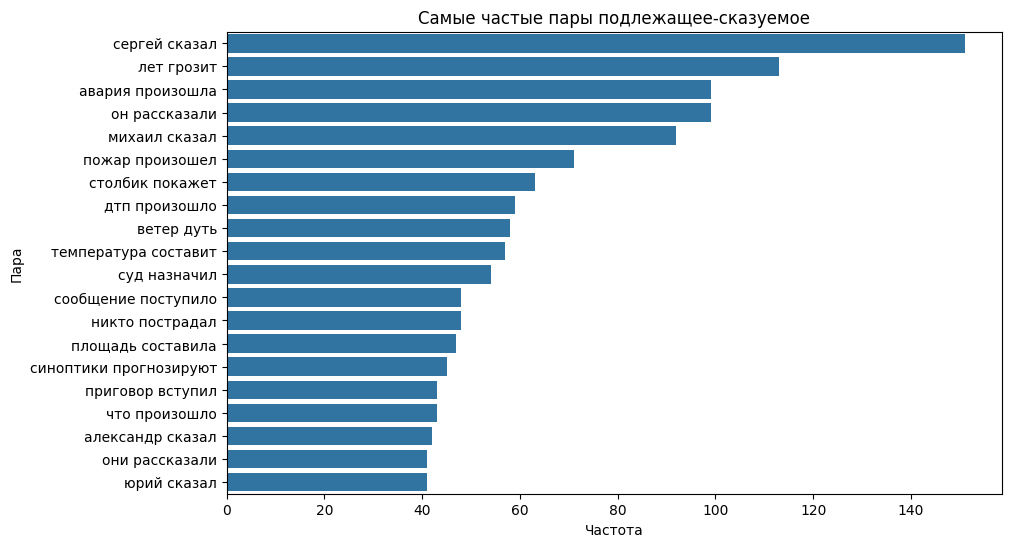

In [14]:
visualize_results(cooccurrences, 20)